<a href="https://colab.research.google.com/github/yoonjinny/ecg_dqn_early_warning/blob/main/ecg_dqn_early_warning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 환경설정

In [14]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [26]:
!git clone https://github.com/yoonjinny/ecg_dqn_early_warning

Cloning into 'ecg_dqn_early_warning'...
remote: Enumerating objects: 99, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 99 (delta 20), reused 3 (delta 3), pack-reused 72 (from 1)
Receiving objects: 100% (99/99), 685.34 KiB | 2.59 MiB/s, done.
Resolving deltas: 100% (26/26), done.


In [27]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle (2).json


{'kaggle (2).json': b'{"username":"yoonjinny","key":"09fae04c30fd2f9126ed841d65bd344a"}'}

In [28]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [29]:
!pip install -q kaggle

In [32]:
import pandas as pd

In [33]:
import pandas as pd

train_df = pd.read_csv(
    "data/mitbih_train.csv",
    header=None
)

train_df.head()

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
train_df.shape

(87554, 188)

# 데이터 전처리

## 1. 데이터 이해 (정상/비정상 ECG 심전도 데이터)

* 정상 심전도 예시

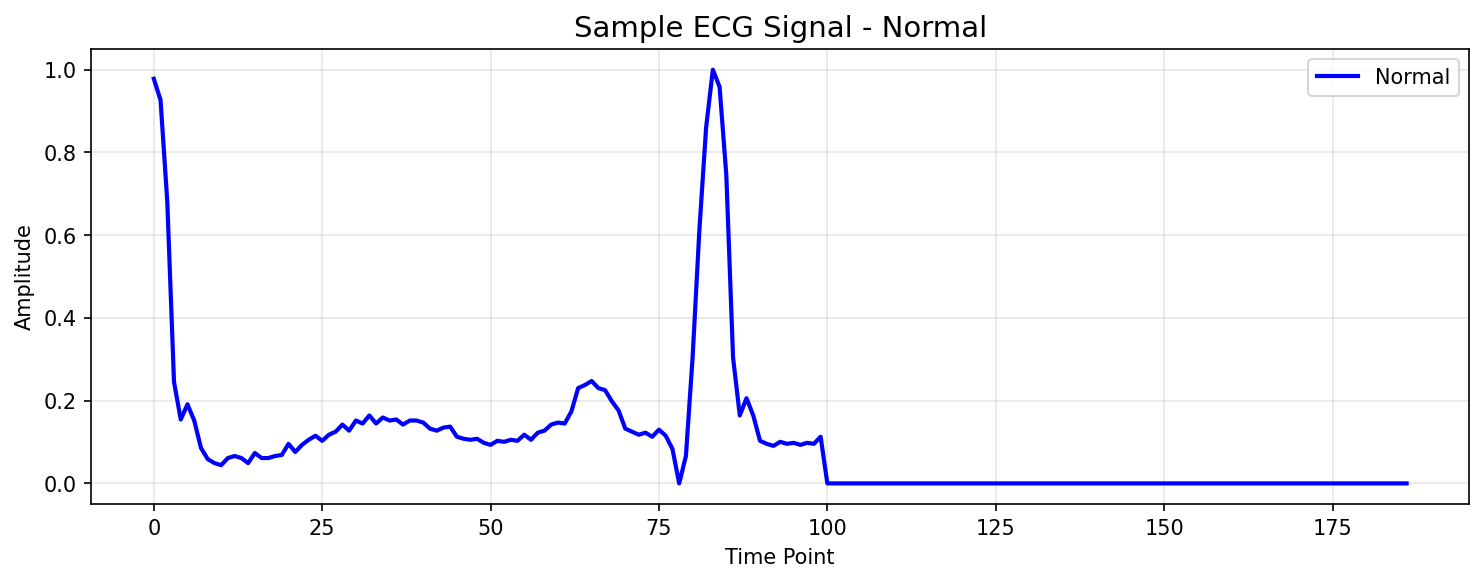

In [79]:
display(Image("results/sample_ecg_normal.png"))

* 비정상 심전도 데이터 예시

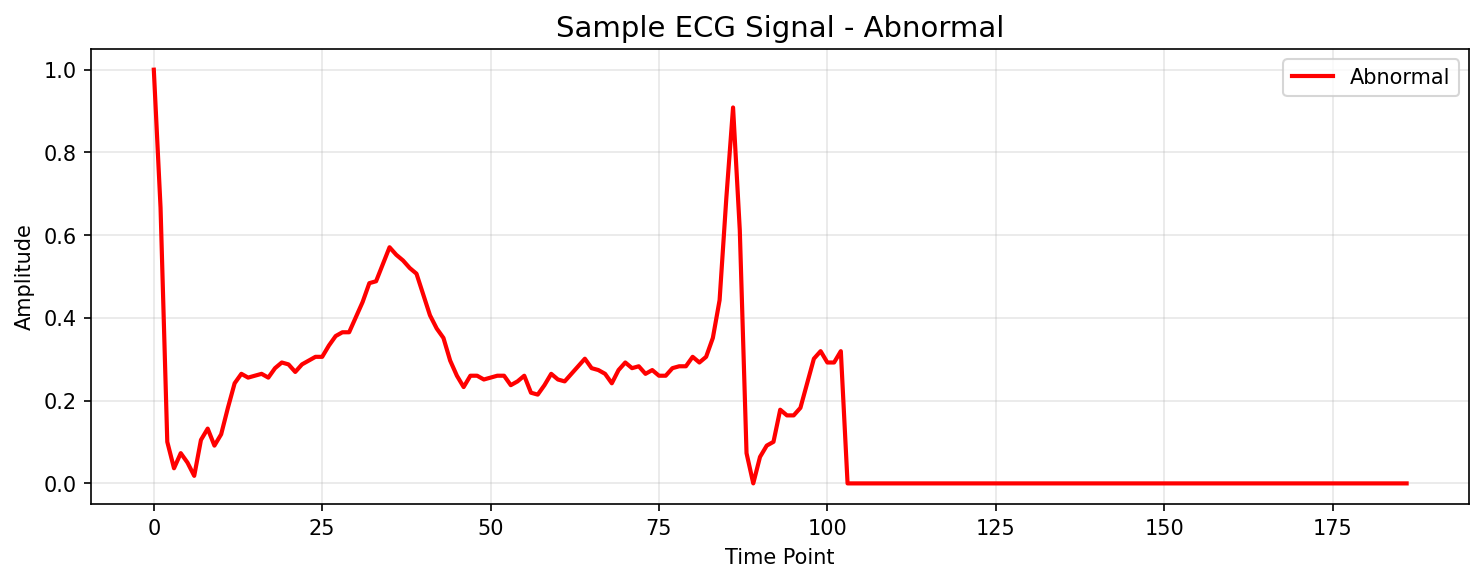

In [80]:
display(Image("results/sample_ecg_abnormal.png"))

## 1. 타겟 라벨링 분포





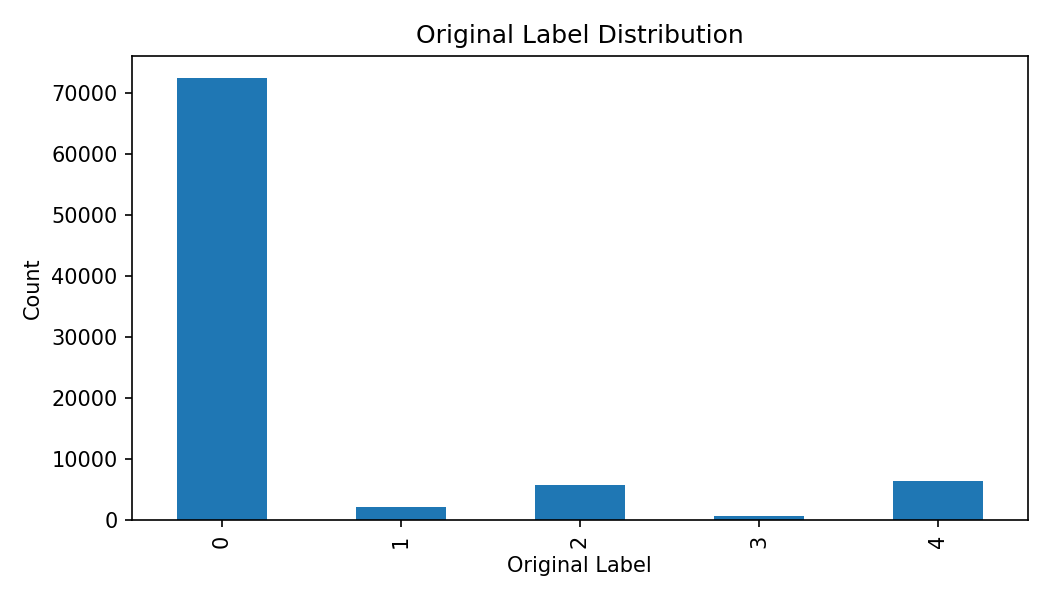

In [77]:
from IPython.display import Image, display

display(Image("results/original_label_distribution.png"))

In [76]:
!python src/data.py

1. Dataset Load
CSV Path  : data/mitbih_train.csv
Raw Shape : (87554, 188)

Original Label Distribution
0    72471
1     2223
2     5788
3      641
4     6431
Name: count, dtype: int64

Label Mapping
Original 0   -> Normal(0)
Original 1~4 -> Abnormal(1)

Binary Label Distribution
0    72471
1    15083
Name: count, dtype: int64

[Saved] Label distribution visualizations
results/original_label_distribution.png
results/binary_label_distribution.png
results/binary_label_summary.csv

2. Feature / Label Split
X shape : (87554, 187)
y shape : (87554,)

[Saved] Sample ECG plot: results/sample_ecg_normal.png

[Saved] Sample ECG plot: results/sample_ecg_abnormal.png

3. Train/Test Split
test_size : 0.2
seed      : 42

X_train : (70043, 187)
X_test  : (17511, 187)
y_train : (70043,)
y_test  : (17511,)

Train Label Count
0    57977
1    12066
Name: count, dtype: int64

Test Label Count
0    14494
1     3017
Name: count, dtype: int64

Train Label Ratio
0    0.827734
1    0.172266
Name: proportion, 

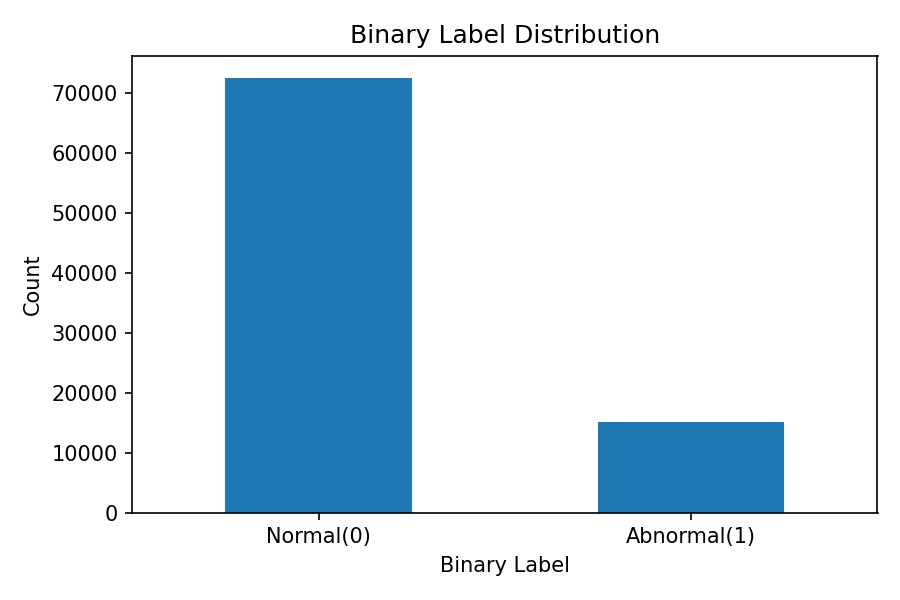

In [78]:
display(Image("results/binary_label_distribution.png"))

# DQN 모델 실험

## E1. 기본 Reward 설정

In [45]:
!pip install -q -r requirements.txt
!python src/train.py

episode=500, avg_reward=-0.337, epsilon=0.677
episode=1000, avg_reward=-0.322, epsilon=0.463
episode=1500, avg_reward=-0.190, epsilon=0.322
episode=2000, avg_reward=-0.316, epsilon=0.230
episode=2500, avg_reward=-0.553, epsilon=0.168
episode=3000, avg_reward=-0.084, epsilon=0.128


In [46]:
!python src/evaluate.py

              precision    recall  f1-score   support

      normal       0.86      0.92      0.89      3624
    abnormal       0.43      0.28      0.34       755

    accuracy                           0.81      4379
   macro avg       0.64      0.60      0.61      4379
weighted avg       0.79      0.81      0.80      4379

accuracy: 0.8111440968257593
f1: 0.3399840383080607
avg_observed_ratio: 0.6995553645070726


In [49]:
%cd /content/ecg_dqn_early_warning

/content/ecg_dqn_early_warning


In [50]:
!grep -n "continue_penalty\|wrong_penalty\|abnormal_reward" src/env.py

13:                 continue_penalty=-0.01, wrong_penalty=-2.0,
14:                 normal_reward=1.0, abnormal_reward=3.0):
18:                continue_penalty=-0.03, wrong_penalty=-3.0,
19:                normal_reward=1.0, abnormal_reward=6.0):
24:        self.continue_penalty = continue_penalty
25:        self.wrong_penalty = wrong_penalty
27:        self.abnormal_reward = abnormal_reward
53:            return self._state(), self.continue_penalty, False, {"forced": False}
58:            base = self.abnormal_reward if y_true == 1 else self.normal_reward
61:            reward = self.wrong_penalty


## E2. Abnormal Detection 강화

In [51]:
!python src/train.py

episode=500, avg_reward=-0.676, epsilon=0.677
episode=1000, avg_reward=-0.613, epsilon=0.463
episode=1500, avg_reward=-0.657, epsilon=0.322
episode=2000, avg_reward=-0.592, epsilon=0.230
episode=2500, avg_reward=-0.549, epsilon=0.168
episode=3000, avg_reward=-0.451, epsilon=0.128


In [52]:
!python src/evaluate.py

              precision    recall  f1-score   support

      normal       0.88      0.93      0.90      3624
    abnormal       0.53      0.37      0.44       755

    accuracy                           0.83      4379
   macro avg       0.70      0.65      0.67      4379
weighted avg       0.82      0.83      0.82      4379

accuracy: 0.8348938113724594
f1: 0.436477007014809
avg_observed_ratio: 0.8726102826689852


## E3. Early Detection 강화

In [53]:
!python src/train.py

episode=500, avg_reward=-0.452, epsilon=0.677
episode=1000, avg_reward=-0.536, epsilon=0.463
episode=1500, avg_reward=-1.276, epsilon=0.322
episode=2000, avg_reward=-1.078, epsilon=0.230
episode=2500, avg_reward=-0.326, epsilon=0.168
episode=3000, avg_reward=-0.604, epsilon=0.128


In [54]:
!python src/evaluate.py

              precision    recall  f1-score   support

      normal       0.93      0.94      0.94      3624
    abnormal       0.72      0.67      0.69       755

    accuracy                           0.90      4379
   macro avg       0.82      0.81      0.82      4379
weighted avg       0.90      0.90      0.90      4379

accuracy: 0.8974651746974195
f1: 0.6935153583617747
avg_observed_ratio: 0.7483614675291529


# Baseline model 비교 분석

## B1. Logistic Regression

In [55]:
!python src/baseline.py

              precision    recall  f1-score   support

      normal       0.95      0.86      0.90      3624
    abnormal       0.53      0.76      0.63       755

    accuracy                           0.84      4379
   macro avg       0.74      0.81      0.76      4379
weighted avg       0.87      0.84      0.85      4379

accuracy: 0.8428865037679836
f1: 0.6256800870511425
observed_ratio: 1.0


## B2. LSTM

In [58]:
!python src/baseline.py

epoch=1, loss=0.6898
epoch=2, loss=0.6885
epoch=3, loss=0.6880
epoch=4, loss=0.6884
epoch=5, loss=0.6877
epoch=6, loss=0.6879
epoch=7, loss=0.6878
epoch=8, loss=0.6871
epoch=9, loss=0.6877
epoch=10, loss=0.6877
              precision    recall  f1-score   support

      normal       0.83      0.99      0.90      3624
    abnormal       0.51      0.06      0.11       755

    accuracy                           0.83      4379
   macro avg       0.67      0.52      0.51      4379
weighted avg       0.78      0.83      0.77      4379

accuracy: 0.828042932176296
f1: 0.11097992916174734
observed_ratio: 1.0


## B3.MLP

In [59]:
!python src/baseline.py

epoch=1, loss=0.4050
epoch=2, loss=0.2753
epoch=3, loss=0.2341
epoch=4, loss=0.2145
epoch=5, loss=0.1962
epoch=6, loss=0.1801
epoch=7, loss=0.1663
epoch=8, loss=0.1690
epoch=9, loss=0.1516
epoch=10, loss=0.1424
epoch=11, loss=0.1363
epoch=12, loss=0.1289
epoch=13, loss=0.1198
epoch=14, loss=0.1244
epoch=15, loss=0.1181
epoch=16, loss=0.1065
epoch=17, loss=0.1076
epoch=18, loss=0.1062
epoch=19, loss=0.0963
epoch=20, loss=0.0938
              precision    recall  f1-score   support

      normal       0.98      0.98      0.98      3624
    abnormal       0.90      0.90      0.90       755

    accuracy                           0.97      4379
   macro avg       0.94      0.94      0.94      4379
weighted avg       0.97      0.97      0.97      4379

accuracy: 0.9659739666590546
f1: 0.9015201586252478
observed_ratio: 1.0


# Seed Experiment

## seed 42

In [69]:
!python src/train.py 42
!python src/evaluate.py 42

SEED = 42
episode=500, avg_reward=-0.568, epsilon=0.677
episode=1000, avg_reward=-0.826, epsilon=0.463
episode=1500, avg_reward=-0.662, epsilon=0.322
episode=2000, avg_reward=-0.295, epsilon=0.230
episode=2500, avg_reward=-0.443, epsilon=0.168
episode=3000, avg_reward=-0.633, epsilon=0.128
SEED = 42
              precision    recall  f1-score   support

      normal       0.92      0.91      0.91      3624
    abnormal       0.58      0.61      0.59       755

    accuracy                           0.86      4379
   macro avg       0.75      0.76      0.75      4379
weighted avg       0.86      0.86      0.86      4379

accuracy: 0.8559031742406942
f1: 0.5947334617854849
avg_observed_ratio: 0.5300040421408448


## seed 77

In [70]:
!python src/train.py 77
!python src/evaluate.py 77

SEED = 77
episode=500, avg_reward=-0.371, epsilon=0.677
episode=1000, avg_reward=-0.603, epsilon=0.463
episode=1500, avg_reward=-0.122, epsilon=0.322
episode=2000, avg_reward=-0.947, epsilon=0.230
episode=2500, avg_reward=-0.519, epsilon=0.168
episode=3000, avg_reward=-0.725, epsilon=0.128
SEED = 77
              precision    recall  f1-score   support

      normal       0.87      0.96      0.91      3624
    abnormal       0.63      0.33      0.43       755

    accuracy                           0.85      4379
   macro avg       0.75      0.65      0.67      4379
weighted avg       0.83      0.85      0.83      4379

accuracy: 0.851564284083124
f1: 0.4337979094076655
avg_observed_ratio: 0.6726403239574391


## seed 14

In [71]:
!python src/train.py 14
!python src/evaluate.py 14

SEED = 14
episode=500, avg_reward=-0.249, epsilon=0.677
episode=1000, avg_reward=-0.825, epsilon=0.463
episode=1500, avg_reward=-0.573, epsilon=0.322
episode=2000, avg_reward=-0.373, epsilon=0.230
episode=2500, avg_reward=-0.384, epsilon=0.168
episode=3000, avg_reward=-0.174, epsilon=0.128
SEED = 14
              precision    recall  f1-score   support

      normal       0.90      0.93      0.92      3624
    abnormal       0.62      0.53      0.57       755

    accuracy                           0.86      4379
   macro avg       0.76      0.73      0.74      4379
weighted avg       0.86      0.86      0.86      4379

accuracy: 0.8625256907969856
f1: 0.5706134094151213
avg_observed_ratio: 0.5057939387426378
